In [2]:
import pandas as pd
import re

INPUT_CSV = "Dataset.csv"
X_OUT = "x_values.csv"
Y_OUT = "y_values.csv"
MAP_OUT = "label_map.csv"
Y_DEBUG_OUT = "y_values_debug.csv"

feature_cols = [
    "I_rms_A", "I_max_A",
    "Amp_50Hz", "Amp_100Hz", "Amp_150Hz", "Amp_200Hz", "Amp_250Hz"
]

label_to_id = {
    "noDevice": 0,
    "loetstation": 1,
    "ventilator": 2,
    "laptobNt": 3,
}

DROP_BAD_ROWS = True
PRINT_BAD_ROWS = True
DROP_UNKNOWN_LABELS = False  # True: unbekannte Labels entfernen | False: abbrechen

def normalize_label(s: str) -> str:
    s = str(s)
    s = s.replace("\ufeff", "")   # BOM
    s = s.replace("\u00a0", " ")  # NBSP -> normales Space
    s = s.replace("\r", "")       # CR raus
    s = s.strip()
    # mehrere Whitespaces zusammenfassen
    s = re.sub(r"\s+", " ", s)
    return s

df = pd.read_csv(INPUT_CSV)

missing = [c for c in feature_cols + ["label"] if c not in df.columns]
if missing:
    raise ValueError(f"Fehlende Spalten in CSV: {missing}")

# Labels normalisieren
df["label"] = df["label"].apply(normalize_label)

# Unbekannte Labels prüfen (und mit repr anzeigen!)
unknown_labels = sorted(set(df["label"].unique()) - set(label_to_id.keys()))
if unknown_labels:
    print("⚠️ Unbekannte Labels gefunden (mit repr, damit man Sonderzeichen sieht):")
    for u in unknown_labels:
        print("  ", repr(u))

    if DROP_UNKNOWN_LABELS:
        df = df[~df["label"].isin(unknown_labels)].copy()
        print(f"✅ Unbekannte Labels entfernt. Übrig: {len(df)} Zeilen")
    else:
        raise ValueError(
            f"Unbekannte Labels gefunden: {unknown_labels}\n"
            f"Erlaubt sind nur: {sorted(label_to_id.keys())}"
        )

# Features numerisch machen
X_num = df[feature_cols].apply(pd.to_numeric, errors="coerce")
bad_feat = X_num.isna().any(axis=1)
bad_label = df["label"].isna() | (df["label"].str.len() == 0)
bad = bad_feat | bad_label
bad_count = int(bad.sum())

if bad_count > 0:
    print(f"⚠️ Gefunden: {bad_count} fehlerhafte Zeilen (NaN/leer)")

    if PRINT_BAD_ROWS:
        print("Indices:", df.index[bad].tolist())
        print(df.loc[bad, feature_cols + ["label"]])

    if DROP_BAD_ROWS:
        df = df.loc[~bad].copy()
        X_num = X_num.loc[~bad].copy()
        print(f"✅ Schlechte Zeilen entfernt. Übrig: {len(df)} Zeilen")
    else:
        raise ValueError("Abbruch wegen fehlerhaften Zeilen (setze DROP_BAD_ROWS=True zum Entfernen).")

# X schreiben
X = X_num.astype("float32")
X.to_csv(X_OUT, index=False)

# y schreiben
y = df["label"].map(label_to_id).astype("int32")
pd.DataFrame({"y": y}).to_csv(Y_OUT, index=False)

# Debug
pd.DataFrame({"y": y, "label": df["label"]}).to_csv(Y_DEBUG_OUT, index=False)

# Mapping schreiben
pd.DataFrame({"label": list(label_to_id.keys()), "id": list(label_to_id.values())}).to_csv(MAP_OUT, index=False)

print("✅ Fertig")
print("X:", X_OUT, "shape =", X.shape)
print("y:", Y_OUT, "shape =", y.shape)
print("y debug:", Y_DEBUG_OUT)
print("Mapping:", MAP_OUT)
print("Label->ID:", label_to_id)


✅ Fertig
X: x_values.csv shape = (80, 7)
y: y_values.csv shape = (80,)
y debug: y_values_debug.csv
Mapping: label_map.csv
Label->ID: {'noDevice': 0, 'loetstation': 1, 'ventilator': 2, 'laptobNt': 3}



=== Split-Größen ===
{'Train': 56, 'Valid': 12, 'Test': 12, 'Total': 80}

=== Klassenverteilung (Anzahl/Prozent) ===
      Label       Split  Anzahl  Prozent
   noDevice Train (70%)      14     25.0
loetstation Train (70%)      14     25.0
 ventilator Train (70%)      14     25.0
   laptobNt Train (70%)      14     25.0
   noDevice Valid (15%)       3     25.0
loetstation Valid (15%)       3     25.0
 ventilator Valid (15%)       3     25.0
   laptobNt Valid (15%)       3     25.0
   noDevice  Test (15%)       3     25.0
loetstation  Test (15%)       3     25.0
 ventilator  Test (15%)       3     25.0
   laptobNt  Test (15%)       3     25.0

=== Pivot (Anzahl) ===
Split        Test (15%)  Train (70%)  Valid (15%)
Label                                            
noDevice              3           14            3
loetstation           3           14            3
ventilator            3           14            3
laptobNt              3           14            3

=== Pivot (Prozent) ===


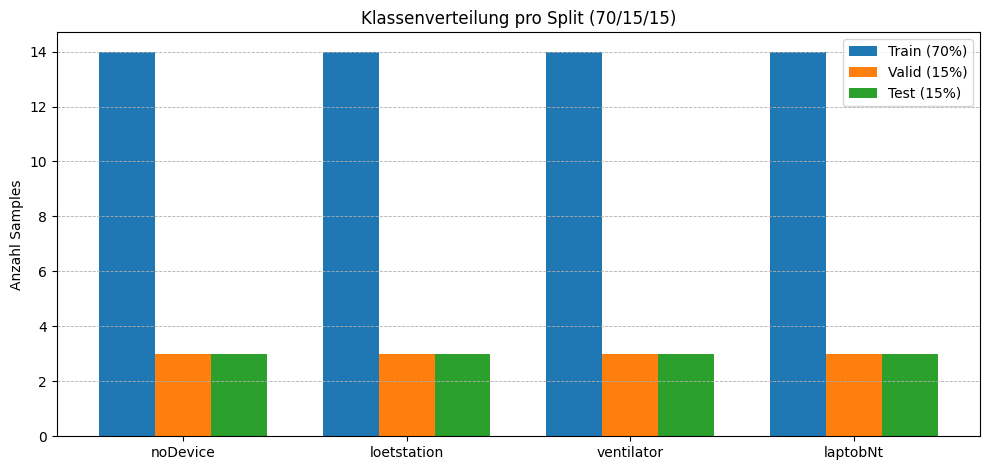


✅ Gespeichert: Dataset_train.csv, Dataset_val.csv, Dataset_test.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# =============================
# Einstellungen
# =============================
DATASET_PATH = "Dataset.csv"

LABEL_ORDER = ["noDevice", "loetstation", "ventilator", "laptobNt"]
NAME_TO_ID = {name: i for i, name in enumerate(LABEL_ORDER)}
ID_TO_NAME = {i: name for i, name in enumerate(LABEL_ORDER)}

# =============================
# 1) Laden + Labels robust
# =============================
df = pd.read_csv(DATASET_PATH)

if "y" in df.columns:
    y_col = "y"
elif "label" in df.columns:
    y_col = "label"
elif "class" in df.columns:
    y_col = "class"
else:
    raise ValueError("Keine Label-Spalte gefunden (y/label/class).")

raw_y = df[y_col]

if pd.api.types.is_numeric_dtype(raw_y):
    y_id = raw_y.astype(int)
    df["label_name"] = y_id.map(ID_TO_NAME).fillna("unknown")
else:
    y_str = raw_y.astype(str).str.strip()
    y_id = y_str.map(NAME_TO_ID)
    if y_id.isna().any():
        unknown = sorted(set(y_str[y_id.isna()]))
        raise ValueError(f"Unbekannte Label-Werte: {unknown}")
    y_id = y_id.astype(int)
    df["label_name"] = y_str

df["y_id"] = y_id

# =============================
# 2) Split 70/15/15 (stratifiziert)
# =============================
df_train, df_tmp = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["y_id"]
)
df_val, df_test = train_test_split(
    df_tmp, test_size=0.50, random_state=42, stratify=df_tmp["y_id"]
)

# =============================
# 3) Tabellen (Counts + Prozent)
# =============================
def split_summary(name, part_df):
    counts = part_df["label_name"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    total = len(part_df)
    perc = (counts / total * 100.0).round(2)
    out = pd.DataFrame({
        "Label": counts.index,
        "Split": name,
        "Anzahl": counts.values.astype(int),
        "Prozent": perc.values
    })
    return out

summary = pd.concat([
    split_summary("Train (70%)", df_train),
    split_summary("Valid (15%)", df_val),
    split_summary("Test (15%)",  df_test),
], ignore_index=True)

print("\n=== Split-Größen ===")
print({"Train": len(df_train), "Valid": len(df_val), "Test": len(df_test), "Total": len(df)})

print("\n=== Klassenverteilung (Anzahl/Prozent) ===")
print(summary.to_string(index=False))

pivot_counts = summary.pivot_table(
    index="Label", columns="Split", values="Anzahl", aggfunc="sum", fill_value=0
).reindex(LABEL_ORDER).astype(int)

pivot_perc = summary.pivot_table(
    index="Label", columns="Split", values="Prozent", aggfunc="mean", fill_value=0
).reindex(LABEL_ORDER)

print("\n=== Pivot (Anzahl) ===")
print(pivot_counts.to_string())

print("\n=== Pivot (Prozent) ===")
print(pivot_perc.round(2).to_string())

# =============================
# 4) Plot (Counts)
# =============================
splits = ["Train (70%)", "Valid (15%)", "Test (15%)"]
x = np.arange(len(LABEL_ORDER))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 4.8))
for i, s in enumerate(splits):
    vals = pivot_counts[s].values if s in pivot_counts.columns else np.zeros(len(LABEL_ORDER), dtype=int)
    ax.bar(x + (i - 1) * width, vals, width, label=s)

ax.set_xticks(x)
ax.set_xticklabels(LABEL_ORDER, rotation=0)
ax.set_ylabel("Anzahl Samples")
ax.set_title("Klassenverteilung pro Split (70/15/15)")
ax.legend()
ax.grid(True, axis="y", linestyle="--", linewidth=0.6)
plt.tight_layout()
plt.show()

# =============================
# 5) Optional: CSVs speichern
# =============================
df_train.to_csv("Dataset_train.csv", index=False)
df_val.to_csv("Dataset_val.csv", index=False)
df_test.to_csv("Dataset_test.csv", index=False)

print("\n✅ Gespeichert: Dataset_train.csv, Dataset_val.csv, Dataset_test.csv")
